In [1]:
from datetime import datetime as dt
import pandas as pd
import pandas_ta as ta
import numpy as np
import torch
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv("/Users/stevenwinatamulia/Documents/skripsi-git//Documents/skripsi/ETHUSDT-4h-2020-2024.csv",delimiter=';')

In [65]:
#change timestamp into datetime
def timestamp_to_datetime(timestamp:list)->list:
    datetime = []
    for i in timestamp:
        datetime.append(dt.fromtimestamp(int(i)/1000))
    return datetime

df['open_time'] = timestamp_to_datetime(df['open_time'])
df['close_time'] = timestamp_to_datetime(df['close_time'])
df.index=df['open_time']

# feature engineering

In [66]:
# add SMA, RSI, and EMA

df['SMA_50'] = ta.sma(df['close'], 50)
df['RSI_14'] = ta.rsi(df['close'], 14)
df['RSI_21'] = ta.rsi(df['close'],21)
df['EMA_20'] = ta.ema(df['close'], 20)
df['EMA_34'] = ta.ema(df['close'], 34)
df = df.join(ta.bbands(df['close'], length=20, std=2))
df = df.join(ta.macd(df['close'], fast=12, slow=26, signal=9))
df_fix = df[[ 'open', 'high', 'low', 'close', 'volume','SMA_50', 'RSI_14', 'EMA_20','RSI_21','EMA_34']]

In [67]:
log_ret = pd.DataFrame()
log_ret['ret_close'] = np.log(df_fix.close) - np.log(df_fix.close.shift(1))
log_ret['sma50'] = df_fix['SMA_50']
log_ret['rsi14'] = df_fix['RSI_14']
log_ret['ema20'] = df_fix['EMA_20']
log_ret['rsi21'] = df_fix['RSI_21']
log_ret['ema34'] = df_fix['EMA_34']
log_ret = log_ret.join(ta.bbands(df['close'], length=30, std=2))
log_ret = log_ret.join(ta.bbands(df['close'], length=31, std=2))
log_ret = log_ret.join(ta.macd(df['close'], fast=12, slow=26, signal=9))
log_ret = log_ret.dropna()

In [68]:
# Pick all the columns that correlation >=0.1 with log-ret
correlation = []
for i in range(log_ret.corr(method='spearman').iloc[0].shape[0]):
    if np.abs(log_ret.corr(method='spearman').iloc[0][i]) >=0.1:
        correlation.append(i)

/var/folders/_8/r2326rms4l37yskjs2yv3mv80000gn/T/ipykernel_1102/3246183226.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.abs(log_ret.corr(method='spearman').iloc[0][i]) >=0.1:


In [69]:
col_name = log_ret.corr(method='spearman').iloc[0][correlation].index
col_name

/var/folders/_8/r2326rms4l37yskjs2yv3mv80000gn/T/ipykernel_1102/579759620.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_name = log_ret.corr(method='spearman').iloc[0][correlation].index


Index(['ret_close', 'rsi14', 'rsi21', 'BBP_30_2.0', 'BBP_31_2.0',
       'MACDh_12_26_9'],
      dtype='object')

# Data Fix (after cleaning and engineering)

In [70]:
XY_data = log_ret[col_name]

In [71]:
# Make the dataset for model train
XY_data['y'] = XY_data['ret_close'].shift(-1)
XY_data.columns = ['log_return','rsi14','rsi21','BB30','BB31','MACD','y']
XY_data.tail()

/var/folders/_8/r2326rms4l37yskjs2yv3mv80000gn/T/ipykernel_1102/1514433908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XY_data['y'] = XY_data['ret_close'].shift(-1)


,log_return,rsi14,rsi21,BB30,BB31,MACD,y
open_time,,,,,,,
2024-09-30 11:00:00,0.003062,46.236617,50.622382,0.405491,0.412349,-6.855071,-0.003316
2024-09-30 15:00:00,-0.003316,43.949577,49.088132,0.336007,0.340391,-7.393437,-0.012606
2024-09-30 19:00:00,-0.012606,36.598073,43.828611,0.080785,0.101049,-9.526301,-0.000216
2024-09-30 23:00:00,-0.000216,36.486268,43.744894,0.044491,0.101339,-10.459905,0.002694
2024-10-01 03:00:00,0.002694,38.995063,45.120723,0.074759,0.124045,-10.086594,NaN


In [72]:
log_ret = XY_data.log_return

# 3 Sigma Check

In [90]:
count = 0
for i in log_ret:
    if i < log_ret.mean() - 3 * log_ret.std() or i >log_ret.mean() + 3 * log_ret.std():
        count+=1

In [91]:
print(count)

184


In [93]:
184 / len(log_ret) *100

1.7798413619655638

# Check Normality

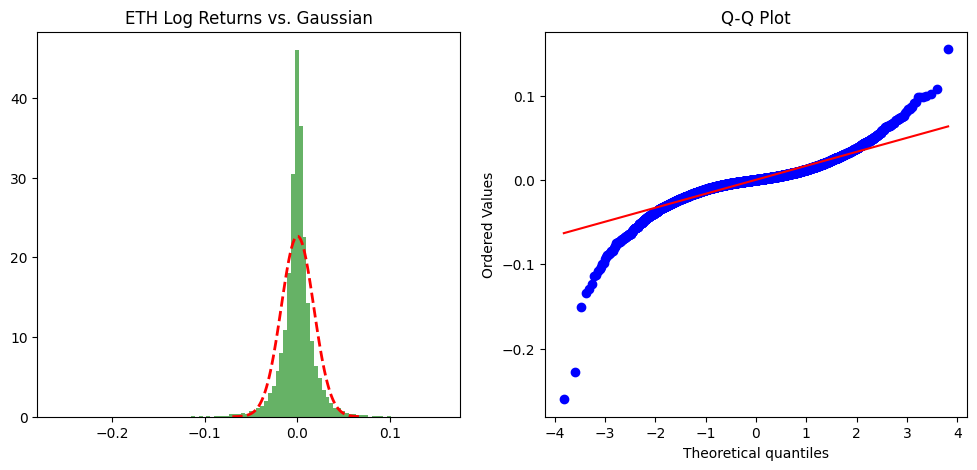

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Plot histogram vs. normal distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(log_ret, bins=100, density=True, alpha=0.6, color='g')
mu, std = np.mean(log_ret), np.std(log_ret)
x = np.linspace(mu - 4*std, mu + 4*std, 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r--', linewidth=2)
plt.title("ETH Log Returns vs. Gaussian")

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [74]:
# Shapiro-Wilk (small samples) / Kolmogorov-Smirnov (large samples)
kstest_p = stats.kstest(log_ret, 'norm', args=(mu, std))[1]  # H0: data matches N(mu, std)

print(f"KS p-value: {kstest_p:.3f}")        # Likely p ≈ 0 (reject H0)

KS p-value: 0.000


If p < 0.05, reject normality. ETH log returns are not Gaussian.

# 3 std Method Outliers

In [75]:
z_scores = (log_ret - mu) / std
outliers = np.abs(z_scores) > 3 # 3σ threshold
outlier_pct = 100 * np.sum(outliers) / len(log_ret)

print(f"Outliers (>3σ): {outlier_pct:.2f}%")

Outliers (>3σ): 1.78%


# IQR Method Outliers

In [76]:
import numpy as np

# Calculate quartiles and IQR
Q1 = np.percentile(log_ret, 25)
Q3 = np.percentile(log_ret, 75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_mask = (log_ret < lower_bound) | (log_ret > upper_bound)
outliers = log_ret[outliers_mask]
outlier_pct = 100 * len(outliers) / len(log_ret)

print(f"IQR: {IQR:.4f}")
print(f"Lower Bound: {lower_bound:.4f}, Upper Bound: {upper_bound:.4f}")
print(f"Outliers Detected: {len(outliers)} ({outlier_pct:.2f}%)")

IQR: 0.0136
Lower Bound: -0.0266, Upper Bound: 0.0277
Outliers Detected: 1004 (9.71%)


**Claude AI**: </br>
Secara umum, penilaian apakah jumlah outlier "banyak" atau tidak bergantung pada konteks data dan kasus penggunaan, tetapi saya bisa memberikan beberapa panduan:
Untuk metode IQR (9% outlier):

9% outlier dengan metode IQR bisa dianggap cukup besar. Secara teoritis, dalam distribusi normal, metode IQR (dengan batas 1.5 IQR) akan mengidentifikasi sekitar 0.7% data sebagai outlier.
Jika Anda memiliki 9% outlier, ini menunjukkan bahwa distribusi data Anda memiliki ekor yang lebih tebal (heavy-tailed) atau mungkin tidak mengikuti distribusi normal.

Untuk metode Standard Deviation (1.78% outlier):

1.78% outlier dengan metode 3-sigma juga di atas ekspektasi teoritis. Dalam distribusi normal sempurna, hanya sekitar 0.3% data yang akan berada di luar 3 standard deviasi.

Kesimpulan:

Kedua nilai tersebut (9% dan 1.78%) lebih tinggi dari yang diharapkan dalam distribusi normal.
9% outlier dengan metode IQR cukup besar dan mungkin menunjukkan adanya volatilitas tinggi atau peristiwa ekstrem dalam return yang dianalisis.
Perbedaan antara kedua metode (9% vs 1.78%) juga menunjukkan bahwa distribusi return Anda mungkin memiliki karakteristik non-normal yang signifikan.

# undefined mean and infinite variance

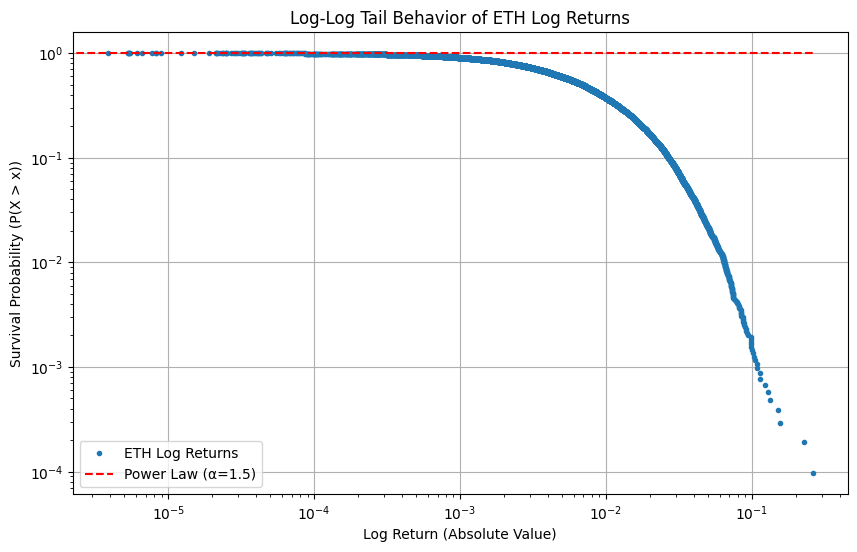

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pareto

# Compute survival function (1 - CDF)
sorted_ret = np.sort(np.abs(log_ret))  # Analyze absolute returns for tail decay
n = len(sorted_ret)
survival = 1 - np.arange(n) / n  # Survival function P(X > x)

# Plot log-log tails
plt.figure(figsize=(10, 6))
plt.loglog(sorted_ret, survival, 'o', markersize=3, label='ETH Log Returns')
plt.xlabel('Log Return (Absolute Value)')
plt.ylabel('Survival Probability (P(X > x))')
plt.title('Log-Log Tail Behavior of ETH Log Returns')
plt.grid(True)

# Compare to theoretical power-law (e.g., α=1.5)
alpha = 1.5
x_pareto = np.linspace(sorted_ret.min(), sorted_ret.max(), 100)
y_pareto = pareto.sf(x_pareto, alpha)  # Survival function for Pareto(α)
plt.loglog(x_pareto, y_pareto, 'r--', label=f'Power Law (α={alpha})')
plt.legend()
plt.show()

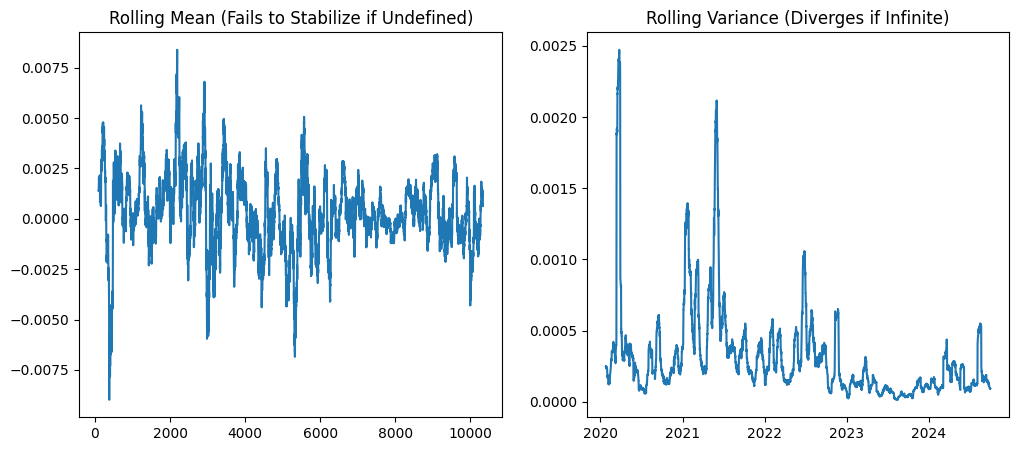

In [16]:
# Compute rolling mean and variance
window_size = 100
normal_returns = np.random.normal(log_ret.mean(), log_ret.std(), 10338)
normal_returns_series = pd.Series(normal_returns)
rolling_mean_nr = normal_returns_series.rolling(window=window_size).mean().values

rolling_mean = log_ret.rolling(window=window_size).mean().values
rolling_var = log_ret.rolling(window=window_size).var()

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# plt.plot(rolling_mean_nr,color='red')
plt.plot(rolling_mean)
plt.title('Rolling Mean (Fails to Stabilize if Undefined)')
plt.subplot(1, 2, 2)
plt.plot(rolling_var)
plt.title('Rolling Variance (Diverges if Infinite)')
plt.show()

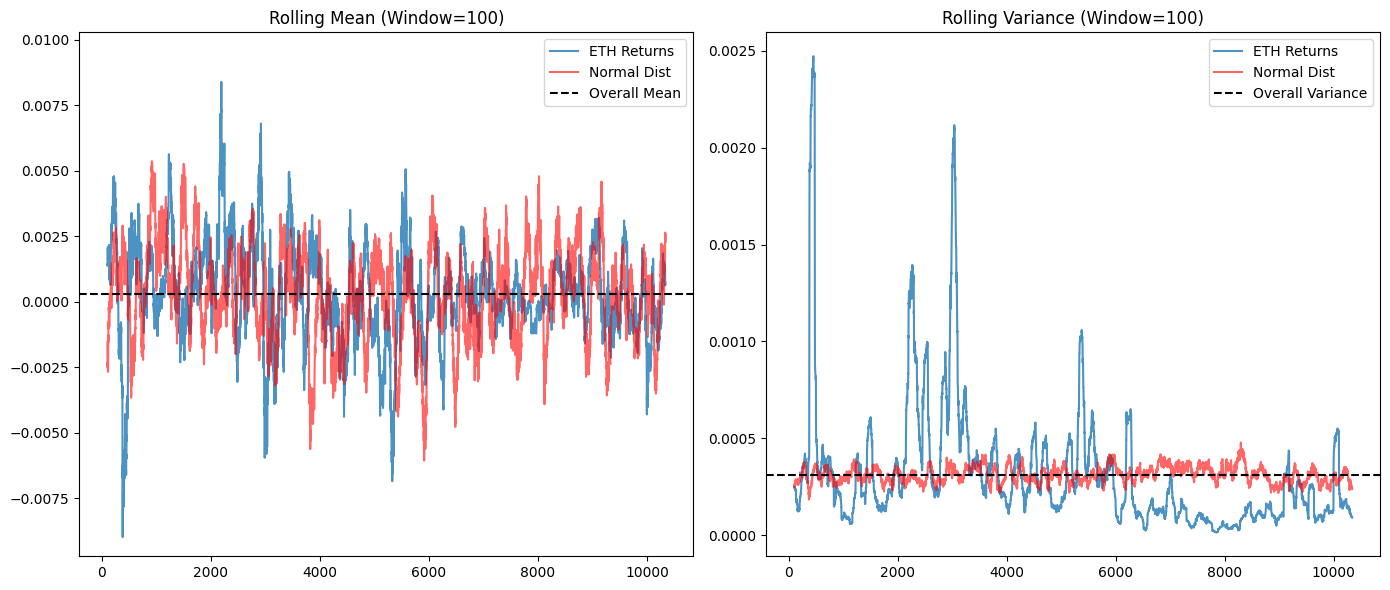

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate normal distribution with same mean/std as ETH returns
normal_returns = np.random.normal(log_ret.mean(), log_ret.std(), len(log_ret))
normal_returns_series = pd.Series(normal_returns)

# Compute rolling statistics (window=100)
window_size = 100
rolling_mean_eth = log_ret.rolling(window=window_size).mean().values
rolling_var_eth = log_ret.rolling(window=window_size).var().values

rolling_mean_norm = normal_returns_series.rolling(window=window_size).mean()
rolling_var_norm = normal_returns_series.rolling(window=window_size).var()

# Plot comparison
plt.figure(figsize=(14, 6))

# Rolling Mean Comparison
plt.subplot(1, 2, 1)
plt.plot(rolling_mean_eth, label='ETH Returns', alpha=0.8)
plt.plot(rolling_mean_norm, label='Normal Dist', color='red', alpha=0.6)
plt.axhline(log_ret.mean(), color='k', linestyle='--', label='Overall Mean')
plt.title('Rolling Mean (Window=100)')
plt.legend()
plt.ylim(log_ret.mean()-0.01, log_ret.mean()+0.01)  # Zoom near mean

# Rolling Variance Comparison
plt.subplot(1, 2, 2)
plt.plot(rolling_var_eth, label='ETH Returns', alpha=0.8)
plt.plot(rolling_var_norm, label='Normal Dist', color='red', alpha=0.6)
plt.axhline(log_ret.var(), color='k', linestyle='--', label='Overall Variance')
plt.title('Rolling Variance (Window=100)')
plt.legend()

plt.tight_layout()
plt.show()

In [79]:
import numpy as np
np.random.seed(17)

# Data normal vs. ETH-like (heavy-tailed)
normal = np.random.normal(0, 0.01, 10000)  # 99.7% data dalam ±0.03
eth_like = log_ret  # 99.7% data dalam ±?? (tak terdefinisi)

print(f"Normal: 99% data dalam [{np.percentile(normal, 0.5):.4f}, {np.percentile(normal, 99.5):.4f}]")
print(f"ETH-like: 99% data dalam [{np.percentile(eth_like, 0.5):.4f}, {np.percentile(eth_like, 99.5):.4f}]")

Normal: 99% data dalam [-0.0265, 0.0258]
ETH-like: 99% data dalam [-0.0666, 0.0624]


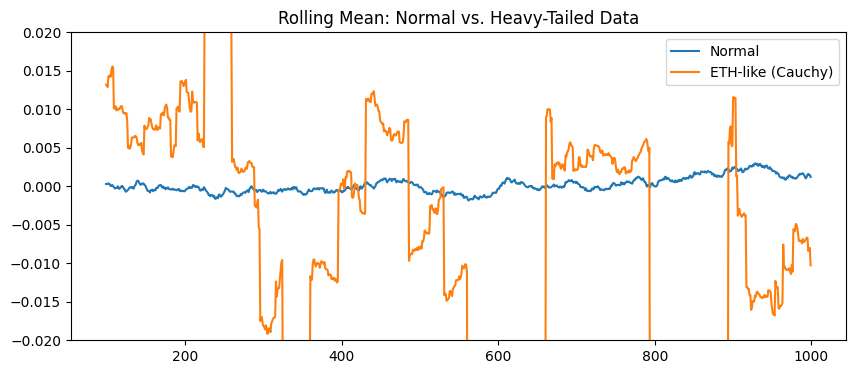

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Normal distribution (μ=0, σ=0.01)
normal_returns = np.random.normal(0, 0.01, 1000)

# ETH-like heavy-tailed distribution (Cauchy, μ=0, γ=0.01)
eth_returns = np.random.standard_cauchy(1000) * 0.01

# Plot rolling mean (window=100)
plt.figure(figsize=(10, 4))
plt.plot(pd.Series(normal_returns).rolling(100).mean(), label='Normal')
plt.plot(pd.Series(eth_returns).rolling(100).mean(), label='ETH-like (Cauchy)')
plt.ylim(-0.02, 0.02)
plt.legend()
plt.title("Rolling Mean: Normal vs. Heavy-Tailed Data")
plt.show()

# ADF Test

H0: The time series is non-stationary. In other words, it has some time-dependent structure and does not have constant variance over time.

HA: The time series is stationary.

In [81]:
from statsmodels.tsa.stattools import adfuller

In [86]:
# log return adf
p_val_adf = adfuller(log_ret)[1]
print(p_val_adf)

2.6262329039635364e-28


In [85]:
# close price adf
p_val_adf = adfuller(df.close)[1]
print(p_val_adf)

0.24335123367716194


# Cauchy Test

In [18]:
import powerlaw
import numpy as np

# Fit power law to absolute log returns (focus on right tail)
fit = powerlaw.Fit(np.abs(log_ret), xmin=np.quantile(np.abs(log_ret), 0.95))  # xmin=top 5% tail

# Get alpha (tail exponent) and p-value
alpha = fit.power_law.alpha
p_value = fit.power_law.xmin  # p-value is stored under `xmin` in recent versions

# Alternatively, use the `distribution_compare` method for formal testing
R, p = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
print(f"Tail exponent (α): {alpha:.2f}")
print(f"p-value (power-law vs. exponential): {p:.3f}")  # p < 0.05 supports power law

Tail exponent (α): 3.95
p-value (power-law vs. exponential): 0.908


Values less than or equal to 0 in data. Throwing out 0 or negative values


In [19]:
# Fit power law, exponential, and log-normal
fit = powerlaw.Fit(np.abs(log_ret))

# Compare power law to alternatives
R_pl_exp, p_pl_exp = fit.distribution_compare('power_law', 'exponential')
R_pl_ln, p_pl_ln = fit.distribution_compare('power_law', 'lognormal')

print(f"Power Law vs. Exponential: R={R_pl_exp:.1f}, p={p_pl_exp:.3f}")
print(f"Power Law vs. Log-normal: R={R_pl_exp:.1f}, p={p_pl_ln:.3f}")

Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit
Power Law vs. Exponential: R=-2.7, p=0.829
Power Law vs. Log-normal: R=-2.7, p=0.003


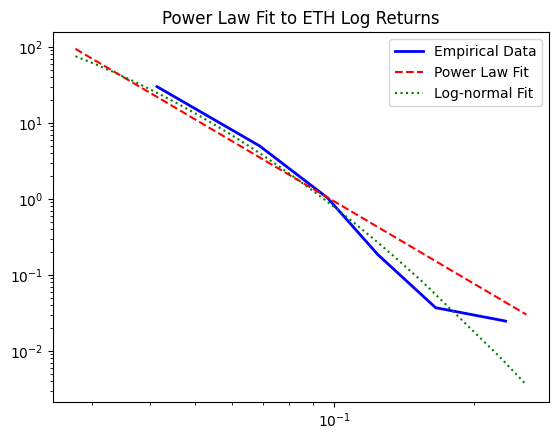

In [20]:
# Plot fitted distributions
fig = fit.plot_pdf(color='b', linewidth=2, label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', ax=fig, label='Power Law Fit')
fit.lognormal.plot_pdf(color='g', linestyle=':', ax=fig, label='Log-normal Fit')
plt.legend()
plt.title("Power Law Fit to ETH Log Returns")
plt.show()

Cauchy parameters - location: 0.000321, scale: 0.006497


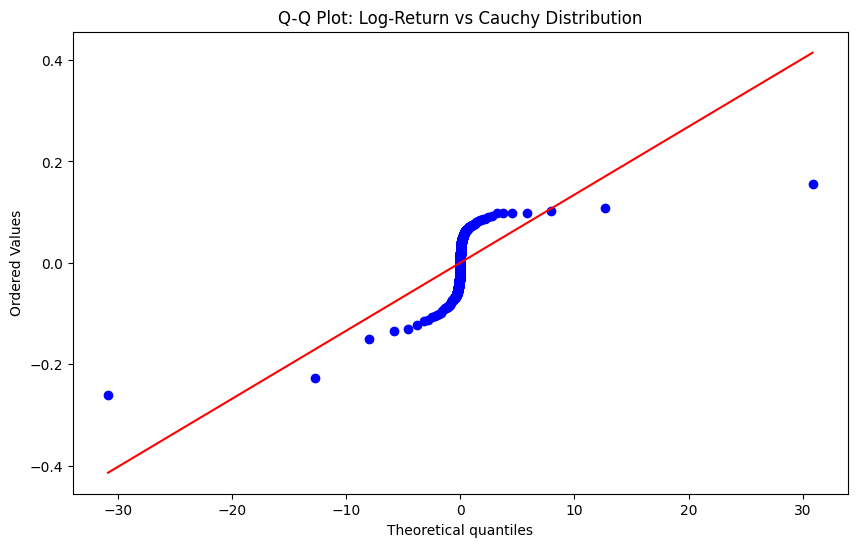

In [21]:


# Fit Cauchy distribution
loc, scale = stats.cauchy.fit(log_ret)
print(f"Cauchy parameters - location: {loc:.6f}, scale: {scale:.6f}")

# Create Q-Q plot
plt.figure(figsize=(10, 6))
stats.probplot(log_ret, dist=stats.cauchy, sparams=(loc, scale), plot=plt)
plt.title('Q-Q Plot: Log-Return vs Cauchy Distribution')
plt.show()

In [22]:
# Kolmogorov-Smirnov test
ks_stat, ks_pval = stats.kstest(log_ret, 'cauchy', args=(loc, scale))
print(f"K-S test: statistic={ks_stat:.6f}, p-value={ks_pval:.6f}")

# Anderson-Darling test (custom implementation needed for Cauchy)

K-S test: statistic=0.032584, p-value=0.000000


In [23]:
# Fit multiple distributions
distributions = [stats.norm, stats.cauchy, stats.t, stats.laplace]
dist_names = ['Normal', 'Cauchy', 'Student t', 'Laplace']
params = {}
aic_values = {}

for dist, name in zip(distributions, dist_names):
    # Fit parameters
    if name == 'Student t':
        # Student t needs special handling
        params[name] = stats.t.fit(log_ret)
        df, loc, scale = params[name]
        loglik = np.sum(stats.t.logpdf(log_ret, df, loc, scale))
    else:
        params[name] = dist.fit(log_ret)
        loglik = np.sum(dist.logpdf(log_ret, *params[name]))
    
    # Calculate AIC
    k = len(params[name])
    aic_values[name] = -2 * loglik + 2 * k
    
# Find best model
best_model = min(aic_values, key=aic_values.get)
print("AIC values:")
for name, aic in aic_values.items():
    print(f"{name}: {aic:.2f}")
print(f"Best model based on AIC: {best_model}")

AIC values:
Normal: -54183.03
Cauchy: -56958.44
Student t: -57800.31
Laplace: -57756.97
Best model based on AIC: Student t


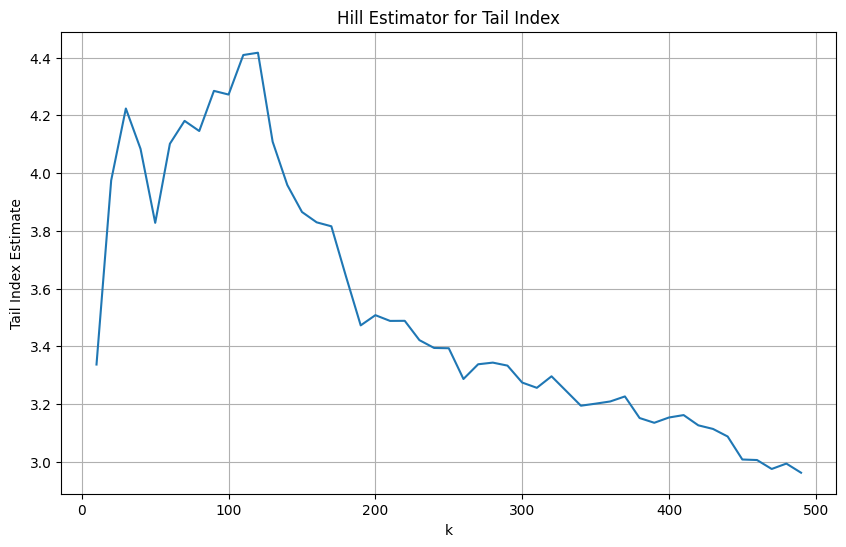

In [24]:
def hill_estimator(data, k):
    # Sort data in descending order
    sorted_data = np.sort(np.abs(data))[::-1]
    n = len(sorted_data)
    if k >= n:
        raise ValueError("k must be less than sample size")
    
    # Calculate Hill estimator
    log_sum = np.sum(np.log(sorted_data[:k])) - k * np.log(sorted_data[k])
    return k / log_sum

# Calculate Hill estimator for different values of k
k_values = np.arange(10, min(500, len(log_ret)), 10)
hill_estimates = [hill_estimator(log_ret, k) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, hill_estimates)
plt.title('Hill Estimator for Tail Index')
plt.xlabel('k')
plt.ylabel('Tail Index Estimate')
plt.grid(True)
plt.show()